## Project_DAMI_042_044_046

<table align="left">
    <tr>
        <td style="text-align:left">Kode Mata Kuliah</td>
        <td style="text-align:left">:</td>
        <td style="text-align:left">12S3205</td>
    </tr>
    <tr>
        <td style="text-align:left">Nama Mata Kuliah</td>
        <td style="text-align:left">:</td>
        <td style="text-align:left">Data Mining</td>
    </tr>
    <tr>
        <td style="text-align:left">Topik</td>
        <td style="text-align:left">:</td>
        <td style="text-align:left"><i>Case 3: House Prices - Advanced Regression
Techniques</i></td>
    </tr>
</table>

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import os

from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# Load Datasets

In [2]:
for dirname, _, filenames in os.walk('./house_prices'):
    for filename in filenames:
        print(filename)

In [4]:
df_train = pd.read_csv('D:/Perkuliahan/SEMESTER 7/DAMI/PROJECT/house-prices-advanced-regression-techniques/train.csv')
print(df_train.shape)

(1460, 81)


In [5]:
df_test = pd.read_csv('D:/Perkuliahan/SEMESTER 7/DAMI/PROJECT/house-prices-advanced-regression-techniques/test.csv')
print(df_test.shape)

(1459, 80)


# Visualizing the Datasets

In [6]:
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [7]:
df_test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [8]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [9]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

# Clean Data

In [10]:
# Find columns with missing values and calculate their counts and percentages
miss_val = df_train.isnull().sum()
miss_val = miss_val[miss_val > 0].sort_values(ascending=False)  # Filter only columns with missing values

# Create a DataFrame to display missing value counts and percentages
miss_val_df = pd.DataFrame({
    'MissingCount': miss_val,
    'Percent': (miss_val / df_test.shape[0] * 100).round(2)  # Calculate percentage and round to 2 decimals
})

miss_val_df


,MissingCount,Percent
PoolQC,1453,99.59
MiscFeature,1406,96.37
Alley,1369,93.83
Fence,1179,80.81
MasVnrType,872,59.77
FireplaceQu,690,47.29
LotFrontage,259,17.75
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


In [11]:
print(df_train.columns)


Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [12]:
# drop columns with high missing values
df_train = df_train.drop(['Fence', 'MiscFeature', 'PoolQC','FireplaceQu','Alley'], axis=1)

In [13]:
# drop rows with any missing values
df_train.dropna(inplace=True)

In [14]:
# Check the dimension of the dataset
df_train.shape

(455, 76)

In [15]:
# Find columns with missing values and calculate their counts and percentages
miss_val = df_test.isnull().sum()
miss_val = miss_val[miss_val > 0].sort_values(ascending=False)  # Filter only columns with missing values

# Create a DataFrame to display missing value counts and percentages
miss_val_df = pd.DataFrame({
    'MissingCount': miss_val,
    'Percent': (miss_val / df_test.shape[0] * 100).round(2)  # Calculate percentage and round to 2 decimals
})

miss_val_df


,MissingCount,Percent
PoolQC,1456,99.79
MiscFeature,1408,96.50
Alley,1352,92.67
Fence,1169,80.12
MasVnrType,894,61.27
FireplaceQu,730,50.03
LotFrontage,227,15.56
GarageCond,78,5.35
GarageYrBlt,78,5.35
GarageQual,78,5.35


In [16]:
print(df_test.columns)

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [17]:
# drop columns with high missing values
df_test = df_test.drop(['Fence', 'MiscFeature', 'PoolQC','FireplaceQu','Alley'], axis=1)

In [18]:
# drop rows with any missing values
df_test.dropna(inplace=True)

In [19]:
df_test.shape

(444, 75)

# Explore Data

In [20]:
print(df_train['SalePrice'].describe())

count       455.000000
mean     224582.446154
std       94618.297457
min       75000.000000
25%      156500.000000
50%      201000.000000
75%      274450.000000
max      755000.000000
Name: SalePrice, dtype: float64


<Axes: xlabel='SalePrice', ylabel='Count'>

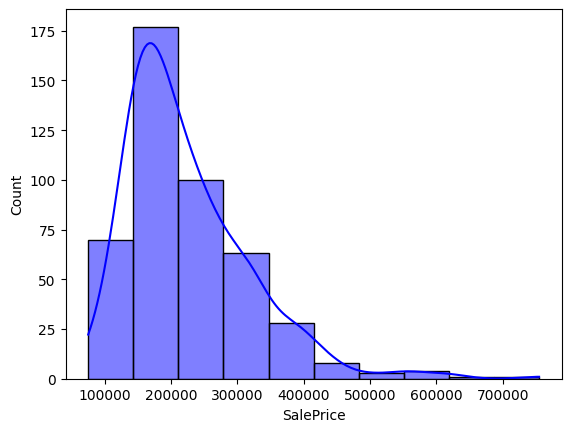

In [21]:
sns.histplot(df_train['SalePrice'], kde=True, bins=10, color='blue')

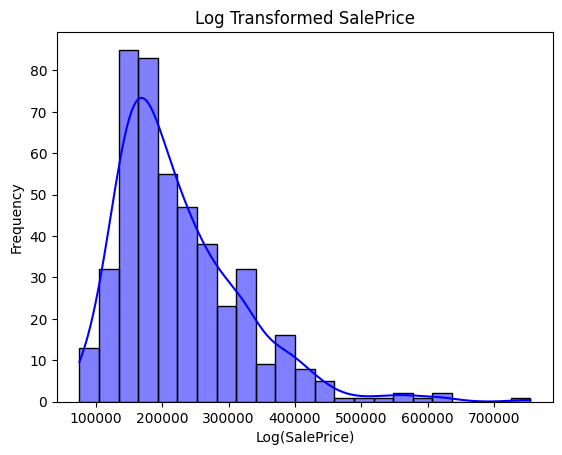

In [23]:
sns.histplot(df_train['SalePrice'], kde=True, color='blue')
plt.title('Log Transformed SalePrice')
plt.xlabel('Log(SalePrice)')
plt.ylabel('Frequency')
plt.show()

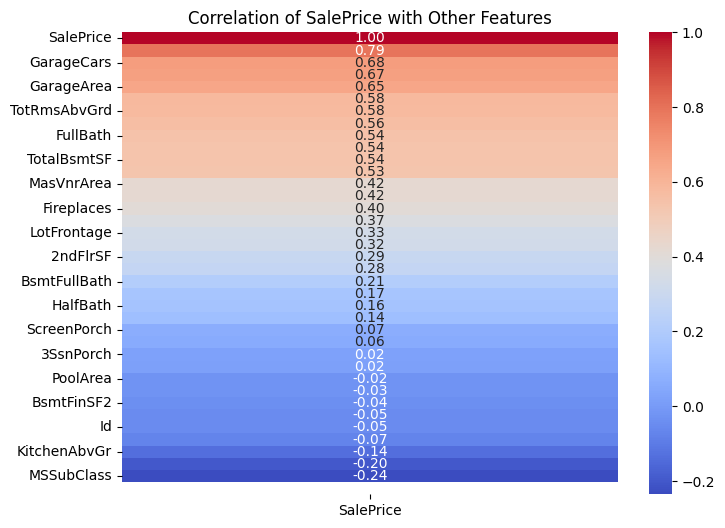

In [24]:
# Filter hanya kolom numerik
numeric_df = df_train.select_dtypes(include=['float64', 'int64'])

# Hitung matriks korelasi
corr_matrix = numeric_df.corr()

# Heatmap
# Correlation of SalePrice with other columns
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix[['SalePrice']].sort_values(by='SalePrice', ascending=False),
            annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title('Correlation of SalePrice with Other Features')
plt.show()



In [25]:
corr_matrix["SalePrice"].sort_values(ascending=False).head(10)

SalePrice       1.000000
OverallQual     0.794180
GarageCars      0.678345
GrLivArea       0.670844
GarageArea      0.648740
YearBuilt       0.584566
TotRmsAbvGrd    0.577539
GarageYrBlt     0.564661
FullBath        0.544830
1stFlrSF        0.541266
Name: SalePrice, dtype: float64

<Axes: xlabel='TotalBsmtSF', ylabel='SalePrice'>

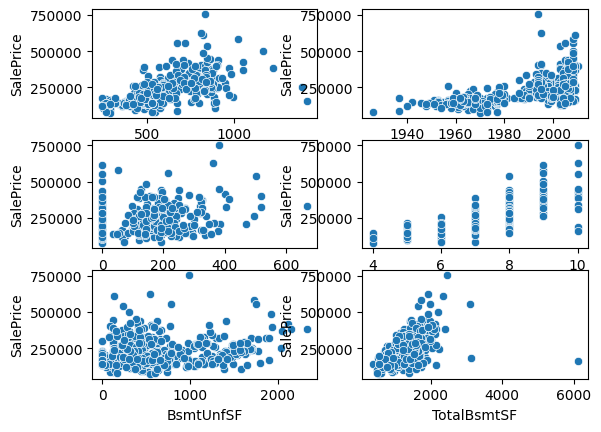

In [26]:
#GarageArea
plt.subplot(321)
sns.scatterplot(data=df_train, x='GarageArea', y="SalePrice")
#YearBuilt
plt.subplot(322)
sns.scatterplot(data=df_train, x='YearBuilt', y="SalePrice")
#WoodDeckSF
plt.subplot(323)
sns.scatterplot(data=df_train, x='WoodDeckSF', y="SalePrice")
#OverallQual
plt.subplot(324)
sns.scatterplot(data=df_train, x='OverallQual', y="SalePrice")
#BsmtUnfSF
plt.subplot(325)
sns.scatterplot(data=df_train, x='BsmtUnfSF', y="SalePrice")
#TotalBsmtSF
plt.subplot(326)
sns.scatterplot(data=df_train, x='TotalBsmtSF', y="SalePrice")

# Train-Test Split Dataset

In [31]:
data = pd.concat([df_train,df_test], axis=0)
y_train = df_train['SalePrice']
data = data.drop(['Id', 'SalePrice'], axis=1)
print(data.shape)

(899, 74)


In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 899 entries, 0 to 1458
Data columns (total 74 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     899 non-null    int64  
 1   MSZoning       899 non-null    object 
 2   LotFrontage    899 non-null    float64
 3   LotArea        899 non-null    int64  
 4   Street         899 non-null    object 
 5   LotShape       899 non-null    object 
 6   LandContour    899 non-null    object 
 7   Utilities      899 non-null    object 
 8   LotConfig      899 non-null    object 
 9   LandSlope      899 non-null    object 
 10  Neighborhood   899 non-null    object 
 11  Condition1     899 non-null    object 
 12  Condition2     899 non-null    object 
 13  BldgType       899 non-null    object 
 14  HouseStyle     899 non-null    object 
 15  OverallQual    899 non-null    int64  
 16  OverallCond    899 non-null    int64  
 17  YearBuilt      899 non-null    int64  
 18  YearRemodAdd  

In [33]:
train =data[:len(y_train)]
test = data[len(y_train):]
#Printing thier shapes
print(df_train.shape, df_test.shape)

(455, 76) (444, 75)


In [34]:
x_train, x_test, y_train, y_test = train_test_split(train, y_train, test_size=0.2, random_state=42)

# Modeling

## Using Random Forest Regressor

In [37]:
#rfr = RandomForestRegressor(n_estimators = 100, max_depth = 5, min_samples_leaf= 5, max_features = 'sqrt')  # using GridSearch
rfr = RandomForestRegressor()
rfr.fit(x_train, y_train) # gets the parameters for the rfr model
rfr_cv = cross_val_score(rfr,X, y, cv = 5, scoring = 'r2')
print("R2: ", rfr_cv.mean())

ValueError: could not convert string to float: 'RL'

In [ ]:
# Random forest determined feature importances
rfr.feature_importances_

# Plotting the Feature Importance

In [ ]:
importance = rfr.feature_importances_

# map feature importance values to the features
feature_importances = zip(importance, X.columns)
#list(feature_importances)

sorted_feature_importances = sorted(feature_importances, reverse = True)
#print(sorted_feature_importances)

top_15_predictors = sorted_feature_importances[0:15]
values = [value for value, predictors in top_15_predictors]
predictors = [predictors for value, predictors in top_15_predictors]
print(predictors)

In [ ]:
# Plot the feature importances of the forest
plt.figure()
plt.title("Feature importances")
plt.bar(range(len(predictors)), values,color="r", align="center");
plt.xticks(range(len(predictors)), predictors, rotation=90);